# 03 — Visualizaciones

Genera las 4 gráficas del tablero a partir de los CSV de análisis.

**Entrada:** `datos/analisis/` (ya está en el repositorio)
**Salida:** archivos HTML en `dashboard/`

Este notebook no necesita Drive — los CSV de análisis son parte del repo.

In [1]:
import sys
EN_COLAB = 'google.colab' in sys.modules
if EN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Corriendo en Colab')
else:
    print('Corriendo en Jupyter local')

Corriendo en Jupyter local


In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import os
from pathlib import Path

In [3]:
if EN_COLAB:
    RUTA_ANALISIS = '/content/drive/MyDrive/ENOE_analisis'
    RUTA_DASH     = '/content/drive/MyDrive/dashboard'
else:
    RAIZ = Path('..').resolve()
    RUTA_ANALISIS = str(RAIZ / 'datos' / 'analisis')
    RUTA_DASH     = str(RAIZ / 'dashboard')

os.makedirs(RUTA_DASH, exist_ok=True)

COLOR_HOMBRE = '#378ADD'
COLOR_MUJER  = '#D4537E'
COLOR_MAPA   = {'Hombre': COLOR_HOMBRE, 'Mujer': COLOR_MUJER}

sn  = pd.read_csv(f'{RUTA_ANALISIS}/serie_nacional.csv',            encoding='utf-8-sig')
bs  = pd.read_csv(f'{RUTA_ANALISIS}/brecha_sector_anio.csv',         encoding='utf-8-sig')
be  = pd.read_csv(f'{RUTA_ANALISIS}/brecha_educ_sector_2025.csv',    encoding='utf-8-sig')
inf = pd.read_csv(f'{RUTA_ANALISIS}/informalidad_contexto_2025.csv', encoding='utf-8-sig')

pivot_sn = sn.pivot(index='anio', columns='sexo', values='mediana_ing_hora').reset_index()
pivot_sn['brecha_pct'] = ((pivot_sn['Hombre'] - pivot_sn['Mujer']) / pivot_sn['Hombre'] * 100).round(1)

print('Datos cargados.')
print(f'  Serie nacional: {sn.shape}  |  Brecha sectorial: {bs.shape}')

Datos cargados.
  Serie nacional: (42, 3)  |  Brecha sectorial: (231, 6)


## G1 — Tendencia nacional 2005–2025

La brecha bajó de 7% en 2005 a 3.3% en 2025 — se redujo a la mitad en 20 años.

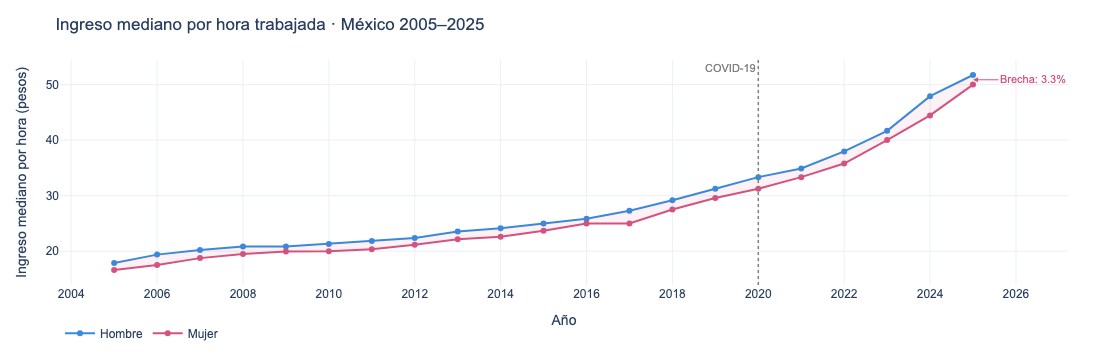

G1 guardada.


In [4]:
hombre = sn[sn['sexo']=='Hombre'].sort_values('anio')
mujer  = sn[sn['sexo']=='Mujer'].sort_values('anio')

fig1 = px.line(
    sn, x='anio', y='mediana_ing_hora', color='sexo',
    color_discrete_map=COLOR_MAPA, markers=True,
    labels={'anio':'Año', 'mediana_ing_hora':'Ingreso mediano por hora (pesos)', 'sexo':''},
    title='Ingreso mediano por hora trabajada · México 2005–2025',
)

# Área sombreada para visualizar la brecha entre las dos líneas
fig1.add_trace(go.Scatter(
    x=list(hombre['anio']) + list(hombre['anio'])[::-1],
    y=list(hombre['mediana_ing_hora']) + list(mujer['mediana_ing_hora'])[::-1],
    fill='toself', fillcolor='rgba(212,83,126,0.08)',
    line=dict(color='rgba(255,255,255,0)'),
    showlegend=False, hoverinfo='skip',
))

fig1.add_vline(x=2020, line_dash='dot', line_color='gray', line_width=1.5,
               annotation_text='COVID-19', annotation_position='top left',
               annotation_font=dict(size=11, color='gray'))

ultimo = pivot_sn[pivot_sn['anio']==2025].iloc[0]
fig1.add_annotation(
    x=2025, y=(ultimo['Hombre']+ultimo['Mujer'])/2,
    text=f"Brecha: {ultimo['brecha_pct']}%",
    showarrow=True, arrowhead=2, ax=60, ay=0,
    font=dict(size=11, color=COLOR_MUJER), arrowcolor=COLOR_MUJER,
)

fig1.update_layout(
    template='plotly_white', hovermode='x unified',
    legend=dict(orientation='h', y=-0.15),
    xaxis=dict(dtick=2), margin=dict(t=60, b=60, l=60, r=40),
    font=dict(family='Arial, sans-serif', size=12),
)
fig1.write_html(f'{RUTA_DASH}/g1_serie_nacional.html')
fig1.show()
print('G1 guardada.')

## G2 — Brecha por sector (2025)

Positivo = hombres ganan más. Los sectores con brecha negativa tienen pocas mujeres
y las que trabajan ahí tienden a ser profesionistas — no es igualdad, es selección.

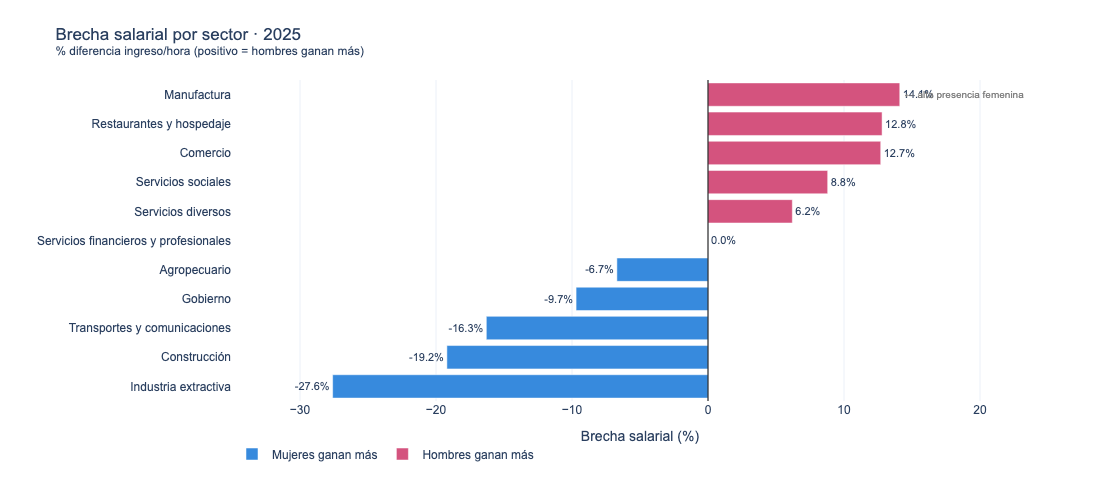

G2 guardada.


In [5]:
bs25 = bs[bs['anio']==2025].sort_values('brecha_pct', ascending=True).copy()
bs25['color_barra'] = bs25['brecha_pct'].apply(
    lambda x: 'Hombres ganan más' if x > 0 else 'Mujeres ganan más'
)

fig2 = px.bar(
    bs25, x='brecha_pct', y='sector',
    color='color_barra',
    color_discrete_map={'Hombres ganan más': COLOR_MUJER, 'Mujeres ganan más': COLOR_HOMBRE},
    orientation='h', text='brecha_pct',
    labels={'brecha_pct':'Brecha salarial (%)', 'sector':'', 'color_barra':''},
    title='Brecha salarial por sector · 2025<br><sup>% diferencia ingreso/hora (positivo = hombres ganan más)</sup>',
)
fig2.update_traces(texttemplate='%{text:.1f}%', textposition='outside', textfont=dict(size=11))
fig2.add_vline(x=0, line_color='black', line_width=1)
fig2.add_annotation(x=14.1, y='Manufactura',
    text=' ← alta presencia femenina', showarrow=False,
    xanchor='left', font=dict(size=10, color='gray'))
fig2.update_layout(
    template='plotly_white', legend=dict(orientation='h', y=-0.12),
    xaxis=dict(zeroline=False, range=[-35, 25]),
    margin=dict(t=80, b=60, l=230, r=60), height=480,
    font=dict(family='Arial, sans-serif', size=12),
)
fig2.write_html(f'{RUTA_DASH}/g2_brecha_sector.html')
fig2.show()
print('G2 guardada.')

## G3 — Heatmap: brecha por sector y nivel educativo (2025)

Responde la pregunta central. Rojo = hombres ganan más. Azul = mujeres ganan más.
En manufactura la brecha persiste en todos los niveles educativos.

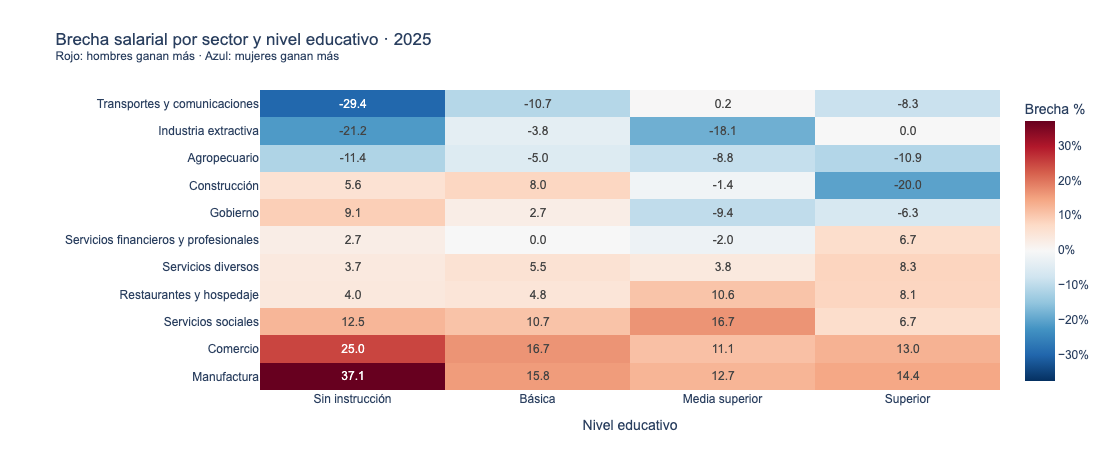

G3 guardada.


In [6]:
be_clean = be[be['nivel_educ'] != 'No especificado'].copy()
orden_educ = ['Sin instrucción', 'Básica', 'Media superior', 'Superior']
be_clean['nivel_educ'] = pd.Categorical(be_clean['nivel_educ'], categories=orden_educ, ordered=True)

hm = be_clean.pivot_table(index='sector', columns='nivel_educ', values='brecha_pct')
hm['_media'] = hm.mean(axis=1)
hm = hm.sort_values('_media', ascending=True).drop(columns='_media')

fig3 = px.imshow(
    hm, color_continuous_scale='RdBu_r', color_continuous_midpoint=0,
    text_auto='.1f', labels={'color':'Brecha (%)'},
    title='Brecha salarial por sector y nivel educativo · 2025<br><sup>Rojo: hombres ganan más · Azul: mujeres ganan más</sup>',
    aspect='auto',
)
fig3.update_layout(
    template='plotly_white', xaxis_title='Nivel educativo', yaxis_title='',
    coloraxis_colorbar=dict(title='Brecha %', ticksuffix='%'),
    margin=dict(t=90, b=60, l=260, r=60), height=450,
    font=dict(family='Arial, sans-serif', size=12),
)
fig3.write_html(f'{RUTA_DASH}/g3_heatmap_educ_sector.html')
fig3.show()
print('G3 guardada.')

## G4 — Ingreso por hora con informalidad como contexto (2025)

Solo los sectores con mayor presencia femenina. La informalidad aparece como
anotación contextual, no como eje principal del análisis.

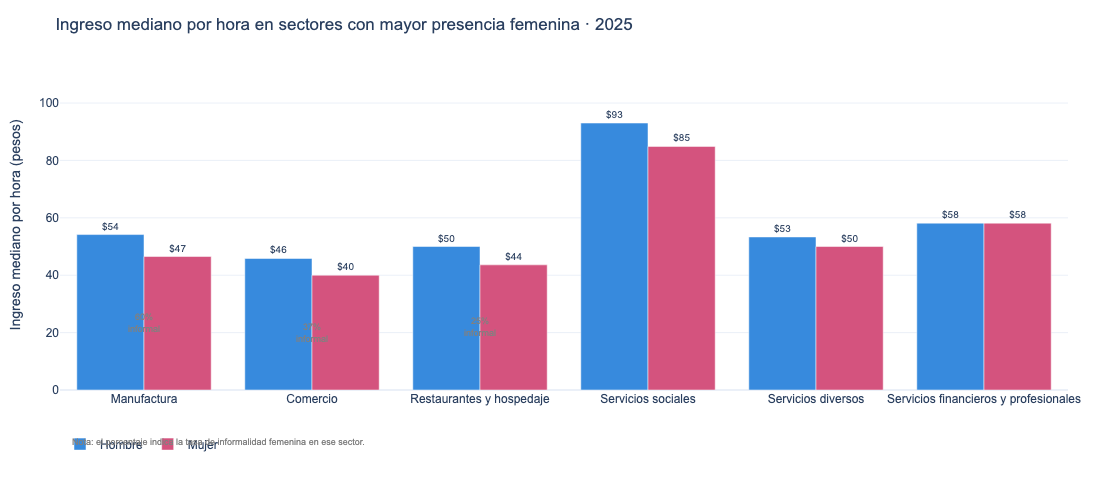

G4 guardada.


In [7]:
sectores_enfoque = [
    'Manufactura', 'Comercio', 'Restaurantes y hospedaje',
    'Servicios sociales', 'Servicios diversos', 'Servicios financieros y profesionales'
]

bs25_focus = bs[bs['anio']==2025].copy()
bs25_focus = bs25_focus[bs25_focus['sector'].isin(sectores_enfoque)]

bs_long = bs25_focus.melt(
    id_vars=['sector', 'brecha_pct'], value_vars=['Hombre', 'Mujer'],
    var_name='sexo', value_name='ingreso_hora'
).sort_values(['brecha_pct', 'sexo'], ascending=[False, True])

fig4 = px.bar(
    bs_long, x='sector', y='ingreso_hora', color='sexo',
    barmode='group', color_discrete_map=COLOR_MAPA, text='ingreso_hora',
    labels={'ingreso_hora':'Ingreso mediano por hora (pesos)', 'sector':'', 'sexo':''},
    title='Ingreso mediano por hora en sectores con mayor presencia femenina · 2025',
    category_orders={'sector': sectores_enfoque},
)
fig4.update_traces(texttemplate='$%{text:.0f}', textposition='outside', textfont=dict(size=10))

# Anotar % informalidad femenina en los 3 sectores con mayor brecha
inf_mujeres = inf[inf['sexo']=='Mujer'].set_index('sector')
for sector in ['Manufactura', 'Comercio', 'Restaurantes y hospedaje']:
    if sector in inf_mujeres.index:
        pct = inf_mujeres.loc[sector, 'pct_informalidad']
        ing_m = bs_long[(bs_long['sector']==sector) & (bs_long['sexo']=='Mujer')]['ingreso_hora'].values
        if len(ing_m) > 0:
            fig4.add_annotation(
                x=sector, y=ing_m[0]*0.5,
                text=f'{pct:.0f}%<br>informal',
                showarrow=False, font=dict(size=9, color='gray'), align='center',
            )

fig4.add_annotation(
    xref='paper', yref='paper', x=0.01, y=-0.18,
    text='Nota: el porcentaje indica la tasa de informalidad femenina en ese sector.',
    showarrow=False, font=dict(size=9, color='gray'), xanchor='left',
)
fig4.update_layout(
    template='plotly_white', legend=dict(orientation='h', y=-0.12),
    margin=dict(t=60, b=90, l=60, r=40), height=480, yaxis=dict(range=[0, 115]),
    font=dict(family='Arial, sans-serif', size=12),
)
fig4.write_html(f'{RUTA_DASH}/g4_ingreso_sector_informalidad.html')
fig4.show()
print('G4 guardada.')

In [8]:
print(f'Archivos en {RUTA_DASH}:')
for a in sorted(os.listdir(RUTA_DASH)):
    if a.endswith('.html'):
        mb = os.path.getsize(f'{RUTA_DASH}/{a}') / 1024
        print(f'  {a}  ({mb:.0f} KB)')

Archivos en /Users/mateos_kvn/HackODS26/LoboEnsambladores/dashboard:
  g1_serie_nacional.html  (4739 KB)
  g2_brecha_sector.html  (4738 KB)
  g3_heatmap_educ_sector.html  (4738 KB)
  g4_ingreso_sector_informalidad.html  (4739 KB)
